TensorFlow executing eagerly: True


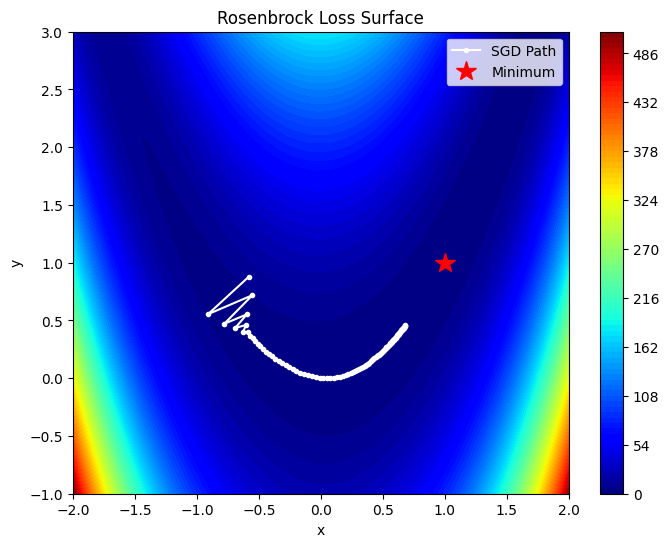

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow executing eagerly:", tf.executing_eagerly())

# Rosenbrock function
def rosenbrock_banana(x, y, a=1.0, b=20.0):
    return (a - x)**2 + b * (y - x**2)**2

# Generate loss surface
def gen_2d_loss_surface(loss_func, n=100):
    x_vals = np.linspace(-2, 2, n)
    y_vals = np.linspace(-1, 3, n)
    X, Y = np.meshgrid(x_vals, y_vals)
    Z = loss_func(X, Y)
    return X, Y, Z

# Plot contour
def plot_contour(X, Y, Z):
    plt.figure(figsize=(8,6))
    plt.contourf(X, Y, Z, levels=100, cmap='jet')
    plt.colorbar()
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("Rosenbrock Loss Surface")

# SGD update
def SGD_update(params, grads, lr):
    for p, g in zip(params, grads):
        p.assign_sub(lr * g)

# Optimization
def optimize():
    # Initial point
    x = tf.Variable(-1.0)
    y = tf.Variable(0.7)

    lr = 0.015
    epochs = 100

    path_x, path_y = [], []

    for i in range(epochs):
        with tf.GradientTape() as tape:
            loss = rosenbrock_banana(x, y)

        grads = tape.gradient(loss, [x, y])
        SGD_update([x, y], grads, lr)

        path_x.append(x.numpy())
        path_y.append(y.numpy())

    return path_x, path_y

# Run everything
X, Y, Z = gen_2d_loss_surface(rosenbrock_banana)
plot_contour(X, Y, Z)

# Run optimization
path_x, path_y = optimize()

# Plot path
plt.plot(path_x, path_y, 'w.-', label="SGD Path")
plt.plot(1, 1, 'r*', markersize=15, label="Minimum")
plt.legend()
plt.show()